In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-238 c,Kepler-238,1,5,Transit,2014.0,Kepler,6.155557,2.390000,152.522000,...,287.897107,40.637814,0,Mini-Neptune,False,True,False,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
1,Kepler-1843 b,Kepler-1843,1,1,Transit,2021.0,Kepler,25.543400,2.709098,7.800000,...,292.885230,41.279169,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
2,TOI-5734 b,TOI-5734,1,1,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),6.184188,2.100000,9.100000,...,111.255818,37.231122,0,Mini-Neptune,False,False,True,Nearby(<100pc),K-type,Short(1-10d)
3,HD 31253 b,HD 31253,1,1,Radial Velocity,2010.0,W. M. Keck Observatory,466.000000,14.100000,197.054600,...,73.682288,12.352010,0,Gas Giant,False,False,False,Nearby(<100pc),F-type,Very-Long(365d+)
4,TOI-762 A b,TOI-762 A,2,1,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),3.471683,8.339482,79.774930,...,166.074742,-47.821496,0,Gas Giant,False,False,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,K2-3 d,K2-3,1,3,Transit,2015.0,K2,44.556030,1.458000,2.200000,...,172.335371,-1.455136,0,Super-Earth,True,True,False,Nearby(<100pc),K-type,Medium(10-100d)
4916,TOI-444 b,TOI-444,1,1,Transit,2023.0,Transiting Exoplanet Survey Satellite (TESS),17.963600,2.770000,8.100000,...,64.183998,-26.766407,0,Mini-Neptune,False,False,True,Nearby(<100pc),G-type(Sun-like),Medium(10-100d)
4917,HD 175541 b,HD 175541,1,1,Radial Velocity,2007.0,W. M. Keck Observatory,298.430000,14.100000,190.062340,...,283.920321,4.264934,0,Gas Giant,False,False,False,Mid(100-500pc),K-type,Long(100-365d)
4918,HD 81688 b,HD 81688,1,1,Radial Velocity,2007.0,Okayama Astrophysical Observatory,183.930000,13.500000,525.688185,...,142.166575,45.600924,0,Gas Giant,False,False,False,Nearby(<100pc),K-type,Long(100-365d)


In [4]:
df_train.columns

Index(['planet_name', 'host_star', 'n_stars', 'n_planets', 'discovery_method',
       'disc_year', 'disc_facility', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
       'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec', 'controversial_flag', 'planet_type',
       'habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery',
       'dist_category', 'star_type', 'orbital_period_cat'],
      dtype='object')

In [5]:
df_train['disc_facility'].value_counts()

disc_facility
Kepler                                          2225
Transiting Exoplanet Survey Satellite (TESS)     601
K2                                               445
Multiple Observatories                           282
La Silla Observatory                             241
                                                ... 
James Webb Space Telescope (JWST)                  1
United Kingdom Infrared Telescope                  1
NASA Infrared Telescope Facility (IRTF)            1
SPECULOOS Southern Observatory                     1
Leoncito Astronomical Complex                      1
Name: count, Length: 69, dtype: int64

In [6]:
df_train['planet_type'].value_counts()

planet_type
Mini-Neptune     1737
Gas Giant        1384
Super-Earth       948
Neptune-like      364
Super-Jupiter     257
Sub-Earth         194
Unknown            36
Name: count, dtype: int64

## Q1. Show dataset info (dtypes/nulls). Identify the earliest discovery year and list the name and facility of the first 5 planets found then.

In [7]:
df_train.isnull().sum()

planet_name                0
host_star                  0
n_stars                    0
n_planets                  0
discovery_method           0
disc_year                  1
disc_facility              0
orbital_period_days      258
planet_radius_earth       36
planet_mass_earth         26
equilibrium_temp_k      1241
orbital_eccentricity     749
semi_major_axis_au       255
star_temp_k              225
star_radius_sun          247
star_mass_sun              7
star_age_gyr            1064
star_surface_gravity     247
star_metallicity         444
dist_from_earth_pc        23
star_vmag                231
ra                         0
dec                        0
controversial_flag         0
planet_type                0
habitable_zone_flag        0
multi_planet_system        0
is_recent_discovery        0
dist_category              0
star_type                  0
orbital_period_cat         0
dtype: int64

In [8]:
df_train.dtypes

planet_name              object
host_star                object
n_stars                   int64
n_planets                 int64
discovery_method         object
disc_year               float64
disc_facility            object
orbital_period_days     float64
planet_radius_earth     float64
planet_mass_earth       float64
equilibrium_temp_k      float64
orbital_eccentricity    float64
semi_major_axis_au      float64
star_temp_k             float64
star_radius_sun         float64
star_mass_sun           float64
star_age_gyr            float64
star_surface_gravity    float64
star_metallicity        float64
dist_from_earth_pc      float64
star_vmag               float64
ra                      float64
dec                     float64
controversial_flag        int64
planet_type              object
habitable_zone_flag        bool
multi_planet_system        bool
is_recent_discovery        bool
dist_category            object
star_type                object
orbital_period_cat       object
dtype: o

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           4920 non-null   object 
 1   host_star             4920 non-null   object 
 2   n_stars               4920 non-null   int64  
 3   n_planets             4920 non-null   int64  
 4   discovery_method      4920 non-null   object 
 5   disc_year             4919 non-null   float64
 6   disc_facility         4920 non-null   object 
 7   orbital_period_days   4662 non-null   float64
 8   planet_radius_earth   4884 non-null   float64
 9   planet_mass_earth     4894 non-null   float64
 10  equilibrium_temp_k    3679 non-null   float64
 11  orbital_eccentricity  4171 non-null   float64
 12  semi_major_axis_au    4665 non-null   float64
 13  star_temp_k           4695 non-null   float64
 14  star_radius_sun       4673 non-null   float64
 15  star_mass_sun        

In [10]:
df_train.loc[df_train['disc_year'].sort_values().head().index , 'planet_name']

2269    PSR B1257+12 d
21      PSR B1257+12 c
3961    PSR B1257+12 b
4413          51 Peg b
1424          55 Cnc b
Name: planet_name, dtype: object

# Insight:
## The dataset contains a mix of numeric (float/int) and categorical (object) data. The earliest year (1992) marks the era of Pulsar Timing discoveries, showing that exoplanet science predates the major satellite missions.

## Q2. Identify the most common discovery method (disc_method). Display value counts of all discovery methods sorted in descending order.

In [11]:
df_train['discovery_method'].value_counts()

discovery_method
Transit                          3612
Radial Velocity                   948
Microlensing                      213
Imaging                            77
Transit Timing Variations          32
Eclipse Timing Variations          16
Orbital Brightness Modulation       8
Pulsar Timing                       7
Astrometry                          5
Disk Kinematics                     1
Pulsation Timing Variations         1
Name: count, dtype: int64

## Insight: As expected, 'Transit' dominates the dataset. This is largely due to the high-throughput nature of the Kepler and TESS missions.

## Q3. Calculate how many exoplanets were discovered each year (disc_year). Create a bar chart showing discoveries per year.


<Axes: xlabel='disc_year'>

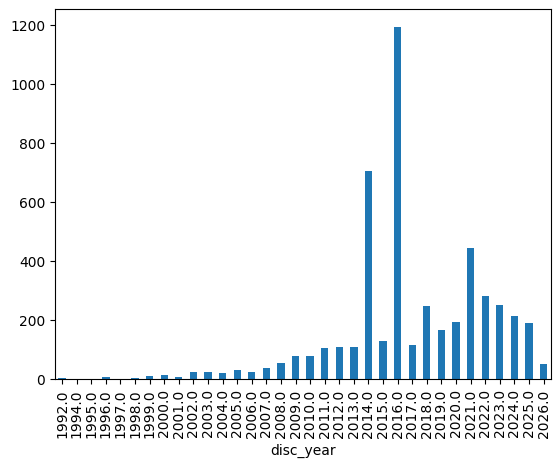

In [12]:
df_train['disc_year'].value_counts().sort_index().plot(kind='bar')

## Insight: The bar chart highlights major 'surges' in discoveries (e.g., 2014 and 2016). These peaks correlate with the release of large data batches from the Kepler Space Telescope.

## Q4. List the top 10 discovery facilities (disc_facility) that discovered the highest number of exoplanets.


<Axes: xlabel='disc_facility'>

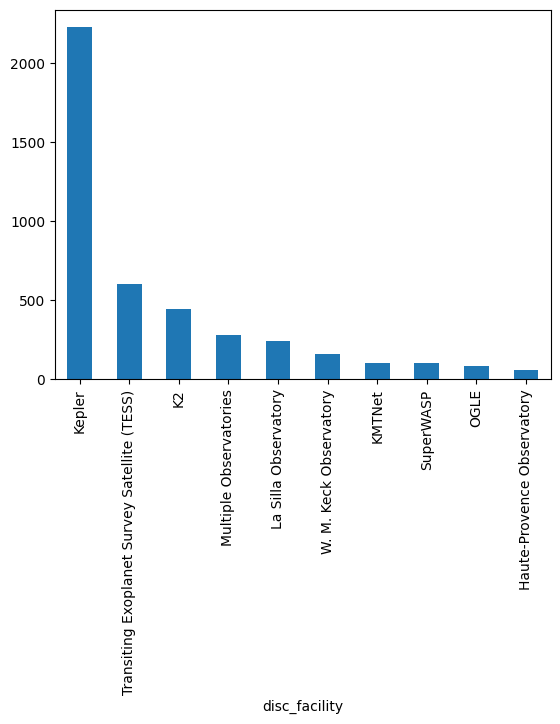

In [13]:
df_train['disc_facility'].value_counts()[:10].plot(kind='bar')

## Q5. Calculate the average orbital period (pl_orbper) and average planet radius (pl_rade) for each discovery method. Present results in a table.


<Axes: xlabel='orbital_period_cat'>

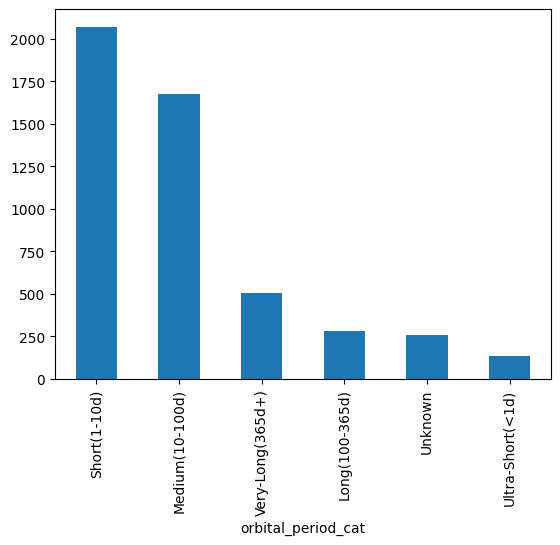

In [14]:
df_train['orbital_period_cat'].value_counts().plot(kind='bar')

In [15]:
import pandas as pd

# Group by discovery_method and compute averages
results = (
    df_train.groupby("discovery_method")[["orbital_period_days", "planet_radius_earth"]]
    .mean()
    .round(3)
)

In [16]:
results

,orbital_period_days,planet_radius_earth
discovery_method,,
Astrometry,3.543140e+02,12.520
Disk Kinematics,NaN,13.300
Eclipse Timing Variations,3.564828e+03,12.929
Imaging,1.842636e+07,13.895
Microlensing,4.176182e+03,9.960
Orbital Brightness Modulation,1.276000e+00,11.401
Pulsar Timing,3.176000e+01,6.250
Pulsation Timing Variations,8.400000e+02,12.400
Radial Velocity,1.592139e+03,9.622


## Q6. Determine how many planets have a radius smaller than Earth (pl_rade < 1). Identify the top 3 discovery methods responsible for finding these planets.

In [17]:
sub_earth = df_train[df_train["planet_radius_earth"] < 1]
n_sub_earth = len(sub_earth)
print(f"Number of planets with radius smaller than Earth: {n_sub_earth}")

Number of planets with radius smaller than Earth: 194


In [18]:
top_methods = sub_earth["discovery_method"].value_counts().head(3)
top_methods

discovery_method
Transit                      183
Radial Velocity                7
Transit Timing Variations      2
Name: count, dtype: int64

## Insight: Out of thousands of entries, only 194 are smaller than Earth. The Transit method is the clear leader here (183 detections), proving that high-precision space telescopes like Kepler and TESS are our best tools for finding 'Earth-like' worlds.

## Q7. Perform missing value analysis: count null values in each column, compute percentage of missing values, and identify the top 3 columns with highest missing data.

In [19]:
missing_pr = df_train.isnull().sum().sort_values(ascending=False)/len(df_train) * 100 

In [20]:
missing_pr.head(3)

equilibrium_temp_k      25.223577
star_age_gyr            21.626016
orbital_eccentricity    15.223577
dtype: float64

In [21]:
missing_pr

equilibrium_temp_k      25.223577
star_age_gyr            21.626016
orbital_eccentricity    15.223577
star_metallicity         9.024390
orbital_period_days      5.243902
semi_major_axis_au       5.182927
star_radius_sun          5.020325
star_surface_gravity     5.020325
star_vmag                4.695122
star_temp_k              4.573171
planet_radius_earth      0.731707
planet_mass_earth        0.528455
dist_from_earth_pc       0.467480
star_mass_sun            0.142276
disc_year                0.020325
n_stars                  0.000000
n_planets                0.000000
host_star                0.000000
planet_name              0.000000
discovery_method         0.000000
disc_facility            0.000000
ra                       0.000000
dec                      0.000000
controversial_flag       0.000000
planet_type              0.000000
habitable_zone_flag      0.000000
multi_planet_system      0.000000
is_recent_discovery      0.000000
dist_category            0.000000
star_type     

## Insight: Significant gaps in 'equilibrium_temp_k' and 'star_age_gyr' suggest that atmospheric and age-related stellar properties are harder to observe than basic orbital parameters.

# Question 8 (Intermediate Level)

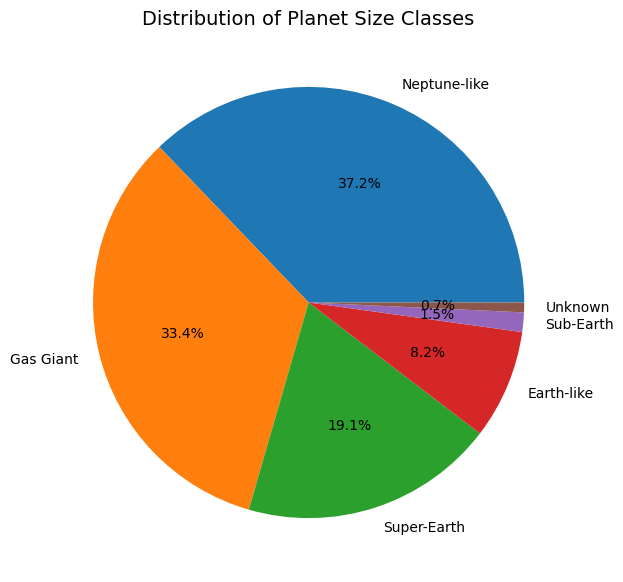

In [22]:
import matplotlib.pyplot as plt
def classify_planet_size(radius): # Define the classification logic
    if pd.isna(radius): return 'Unknown'
    if radius < 0.8: return 'Sub-Earth'
    elif radius < 1.25: return 'Earth-like'
    elif radius < 2.0: return 'Super-Earth'
    elif radius < 6.0: return 'Neptune-like'
    else: return 'Gas Giant'

df_train['planet_size_class'] = df_train['planet_radius_earth'].apply(classify_planet_size) # Create the new column

plt.figure(figsize=(10, 7))

size_counts = df_train['planet_size_class'].value_counts()
plt.pie(size_counts, labels=size_counts.index, autopct='%1.1f%%') #Pie chart showing distribution of planet size classes
plt.title('Distribution of Planet Size Classes', fontsize=14)

plt.show()

## Insight: The pie chart shows that Neptune-like planets and Gas Giants dominate the catalog. They are easier to detect. 'Sub-Earths' represent the smallest slice.

# Question 9 (Advanced Level)

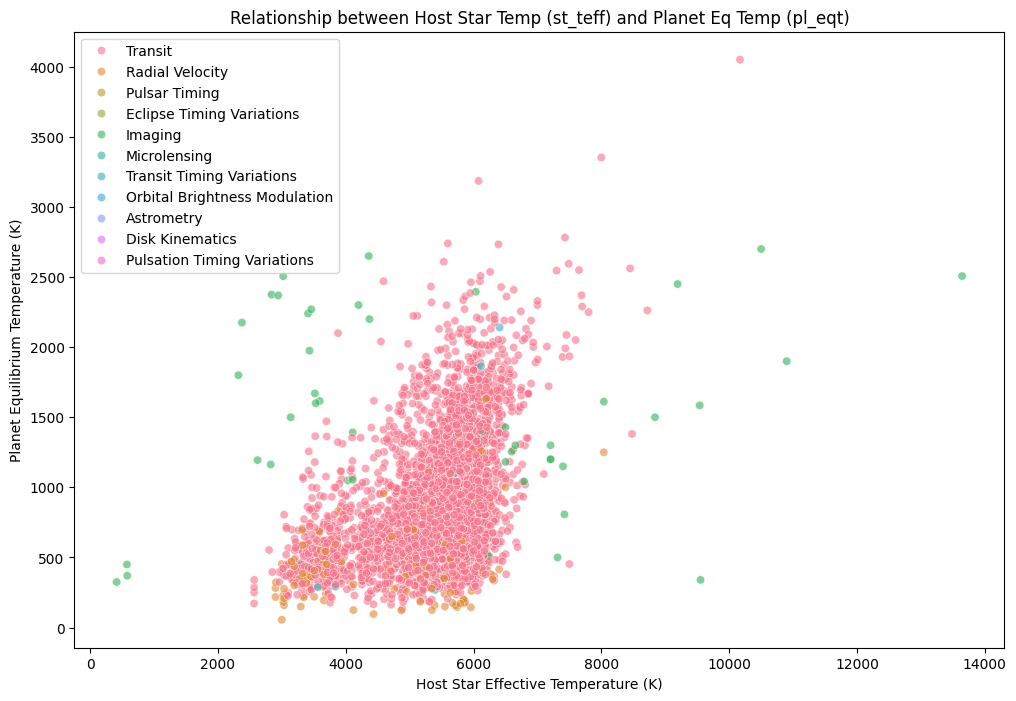

In [23]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_train, x='star_temp_k', y='equilibrium_temp_k', hue='discovery_method', alpha=0.6)

# Formatting
plt.title('Relationship between Host Star Temp (st_teff) and Planet Eq Temp (pl_eqt)')
plt.xlabel('Host Star Effective Temperature (K)')
plt.ylabel('Planet Equilibrium Temperature (K)')
plt.legend()
plt.show()

## Insight: The scatter plot generally shows a positive correlation: hotter stars tend to host hotter planets.

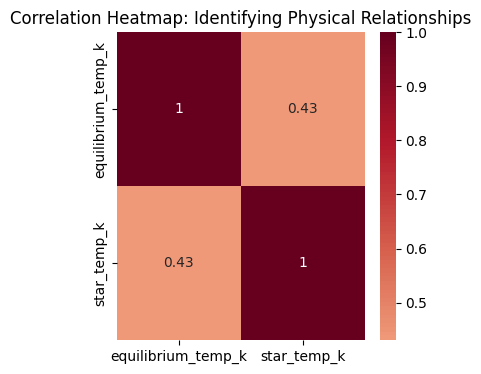

In [24]:
plt.figure(figsize=(4 , 4))
sns.heatmap(df_train[['equilibrium_temp_k' , 'star_temp_k']].corr(), annot=True, cmap='RdBu_r', center=0) # This line calculates the Pearson correlation and plots it as a heatmap.
plt.title('Correlation Heatmap: Identifying Physical Relationships')
plt.show()

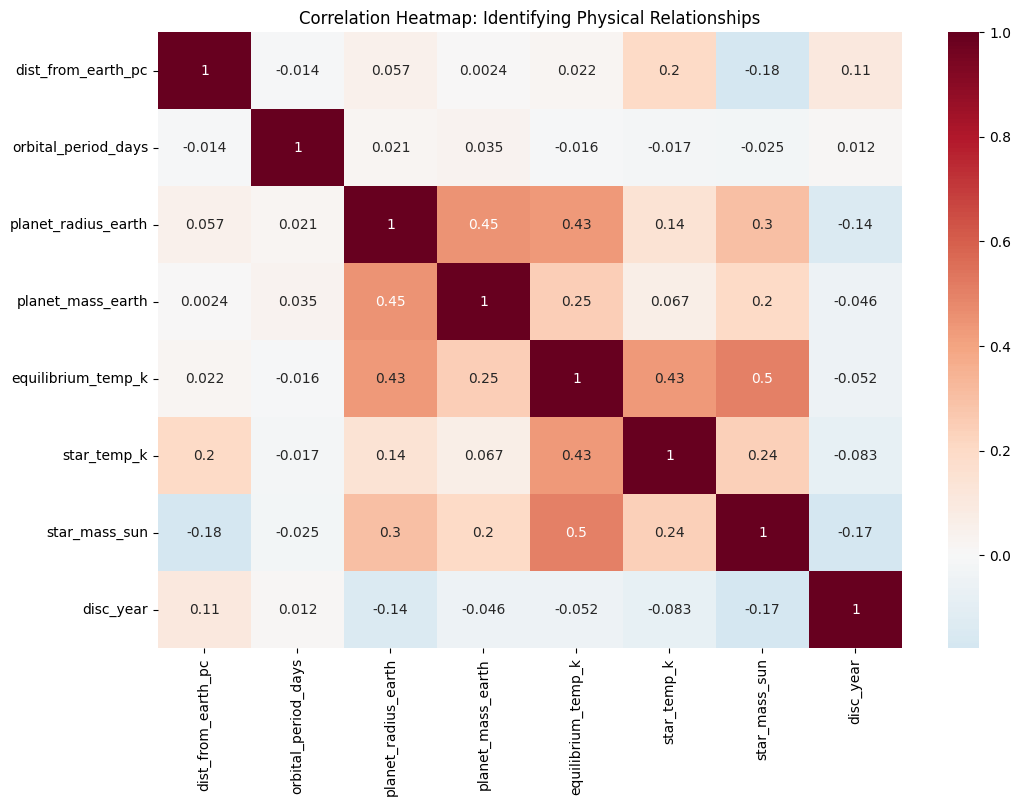

In [25]:
numeric_features = [
    'dist_from_earth_pc', 'orbital_period_days', 'planet_radius_earth', 
    'planet_mass_earth', 'equilibrium_temp_k', 'star_temp_k','star_mass_sun',
    'disc_year'
]

plt.figure(figsize=(12 , 8))
sns.heatmap(df_train[numeric_features].corr(), annot=True, cmap='RdBu_r', center=0) # This line calculates the Pearson correlation and plots it as a heatmap.
plt.title('Correlation Heatmap: Identifying Physical Relationships')
plt.show()

In [26]:
num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

In [27]:
df_train.drop(columns=["planet_name" , "host_star" , "disc_facility"] , inplace=True)   # all feature columns

In [28]:
cat_cols = df_train.select_dtypes(include=["object"]).columns.tolist()
df_train['discovery_method'].value_counts()

discovery_method
Transit                          3612
Radial Velocity                   948
Microlensing                      213
Imaging                            77
Transit Timing Variations          32
Eclipse Timing Variations          16
Orbital Brightness Modulation       8
Pulsar Timing                       7
Astrometry                          5
Disk Kinematics                     1
Pulsation Timing Variations         1
Name: count, dtype: int64

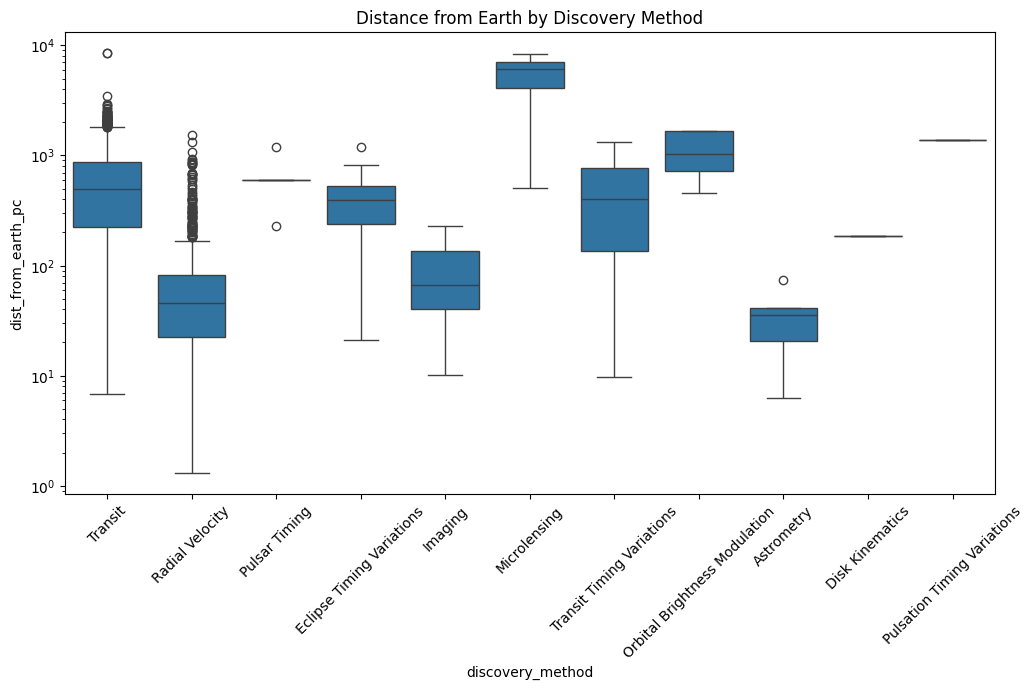

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train, x='discovery_method', y='dist_from_earth_pc')
plt.yscale('log') # Log scale because distances vary from 1pc to 8000pc
plt.xticks(rotation=45)
plt.title('Distance from Earth by Discovery Method')
plt.show()

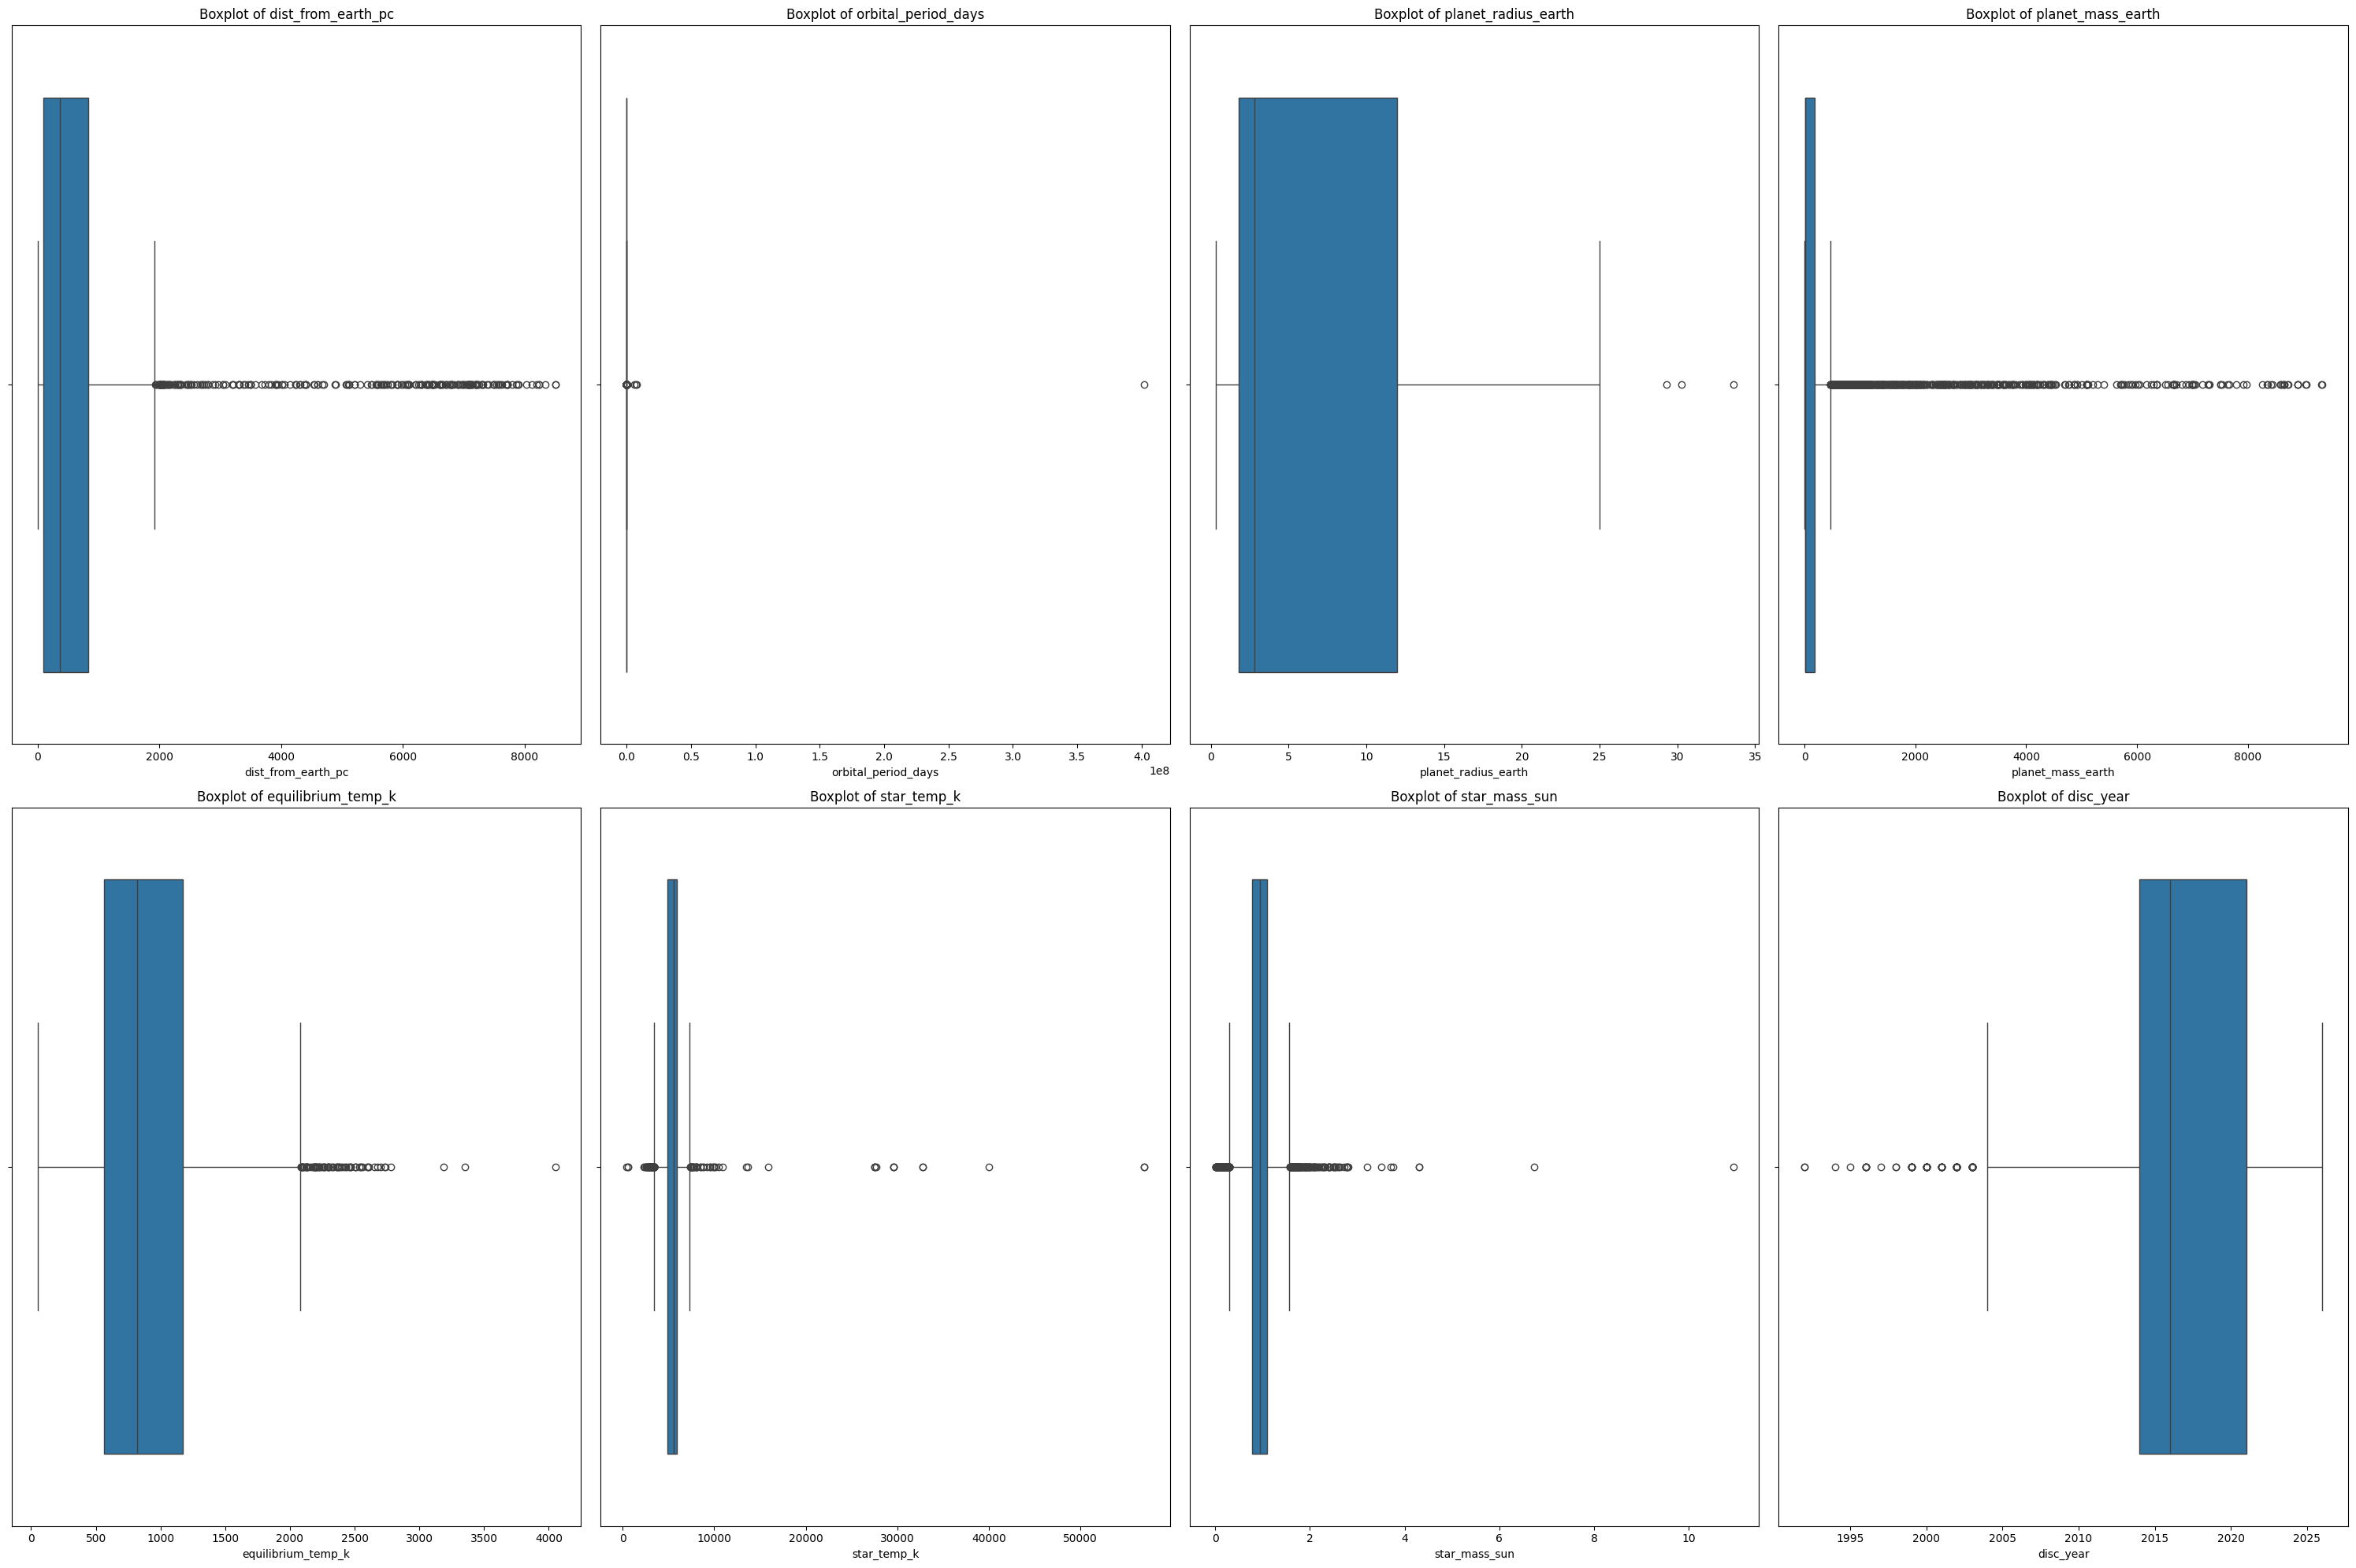

In [31]:
fig , axes = plt.subplots(2 , 4 , figsize=(30 , 20))
for i , col in enumerate(numeric_features) :
    sns.boxplot(x=df_train[col] , ax=axes[i//4 , i%4])
    axes[i//4 , i%4].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [32]:
num_cols

['n_stars',
 'n_planets',
 'disc_year',
 'orbital_period_days',
 'planet_radius_earth',
 'planet_mass_earth',
 'equilibrium_temp_k',
 'orbital_eccentricity',
 'semi_major_axis_au',
 'star_temp_k',
 'star_radius_sun',
 'star_mass_sun',
 'star_age_gyr',
 'star_surface_gravity',
 'star_metallicity',
 'dist_from_earth_pc',
 'star_vmag',
 'ra',
 'dec',
 'controversial_flag']

In [33]:
for col in num_cols : 
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")
    

n_stars: 458 outliers
n_planets: 459 outliers
disc_year: 87 outliers
orbital_period_days: 811 outliers
planet_radius_earth: 3 outliers
planet_mass_earth: 794 outliers
equilibrium_temp_k: 78 outliers
orbital_eccentricity: 503 outliers
semi_major_axis_au: 844 outliers
star_temp_k: 229 outliers
star_radius_sun: 312 outliers
star_mass_sun: 352 outliers
star_age_gyr: 190 outliers
star_surface_gravity: 342 outliers
star_metallicity: 159 outliers
dist_from_earth_pc: 256 outliers
star_vmag: 23 outliers
ra: 0 outliers
dec: 0 outliers
controversial_flag: 37 outliers


# Insight 
## Since there are so many outliers and most numerical columns are not perfectly gaussian , we will use Power Transformer

In [34]:
df_train.shape

(4920, 29)

In [35]:
df_train['discovery_method'].value_counts().values

array([3612,  948,  213,   77,   32,   16,    8,    7,    5,    1,    1])

In [36]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# 1. Prepare features (X) and target (y)
# Replace with your actual column names
X = df_train.drop(columns=["discovery_method"])  # all feature columns
y = df_train["discovery_method"]                 # your class label

class_counts = Counter(y)
print(class_counts)  # [3612, 948, 213, 77, 32, 16, 8, 7, 5, 1, 1]

# Merge classes < 50 into 'Rare'
rare_threshold = 50
y_merged = np.copy(y)
rare_mask = [cls for cls, count in class_counts.items() if count < rare_threshold]
y_merged[np.isin(y, rare_mask)] = "Rare"  # New 'Rare' class

print("After merge:", Counter(y_merged))  # [3612, 948, 213, 77, 32, 16, 8, 7, 5, 1 (Rare)]
y_merged = pd.Series(y_merged , index=y.index)

# 2. Train‑test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_merged, test_size=0.2, random_state=1
)

Counter({'Transit': 3612, 'Radial Velocity': 948, 'Microlensing': 213, 'Imaging': 77, 'Transit Timing Variations': 32, 'Eclipse Timing Variations': 16, 'Orbital Brightness Modulation': 8, 'Pulsar Timing': 7, 'Astrometry': 5, 'Disk Kinematics': 1, 'Pulsation Timing Variations': 1})
After merge: Counter({'Transit': 3612, 'Radial Velocity': 948, 'Microlensing': 213, 'Imaging': 77, 'Rare': 70})


In [37]:
y_train.value_counts()

Transit            2895
Radial Velocity     763
Microlensing        165
Imaging              61
Rare                 52
Name: count, dtype: int64

In [38]:
from  sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder  
le = LabelEncoder()
le.fit(y_merged)
y_train = pd.Series(le.transform(y_train))
y_test = pd.Series(le.transform(y_test))

In [39]:
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

In [40]:
y_train.value_counts()

4    2895
2     763
1     165
0      61
3      52
Name: count, dtype: int64

In [41]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(
    sampling_strategy={4: 1500},  # Target sizes
    random_state=42
)
X_res, y_res = rus.fit_resample(X_train, y_train)
print("Balanced:", Counter(y_res))

Balanced: Counter({4: 1500, 2: 763, 1: 165, 0: 61, 3: 52})


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder 
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.linear_model import LogisticRegression 
from sklearn.impute import KNNImputer
import xgboost as xgb
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import PowerTransformer
from imblearn.combine import SMOTEENN

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# Single ColumnTransformer: impute + one‑hot per group
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),   # KNN imputation for numeric features,  
                ("scaler", StandardScaler()) , 
                ("power", PowerTransformer(method='yeo-johnson', standardize=True))
            ]),
            num_cols
        ),
        (
            "nom_cat",
            Pipeline([
                ("imputer" , SimpleImputer(strategy="most_frequent") ),
                ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
            ]),
            ['planet_type' , 'star_type']
        ),
        (
            "ord_cat",
            Pipeline([
                ("imputer" , SimpleImputer(strategy="most_frequent") ),
                ("ohe", OrdinalEncoder(categories=[['Unknown', 'Nearby(<100pc)' , 'Mid(100-500pc)' , 'Far(500-2kpc)' , 'Distant(2k+pc)'] , ['Unknown', 'Ultra-Short(<1d)' , 'Short(1-10d)' , 'Medium(10-100d)' , 'Long(100-365d)' , 'Very-Long(365d+)']] , handle_unknown="use_encoded_value" , unknown_value=-1))
            ]),
            ['dist_category' , 'orbital_period_cat' ]
        ),
    ],
    remainder="drop"
)

pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("resample", SMOTEENN(sampling_strategy='auto', random_state=42)),
    ("classifier", xgb.XGBClassifier(
                                scale_pos_weight=1.2,
                                class_weight='balanced',  # Auto inverse frequency
                                max_depth = 10,
                                n_estimators=200,
                                random_state=42
                                ))
])


In [43]:
pipe.fit(X_train , y_train)

c:\Users\Gaurav Negi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:23:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessor', ...), ('resample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nom_cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
y_pred = pipe.predict(X_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9603658536585366

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        48
           2       0.88      0.97      0.92       185
           3       0.67      0.44      0.53        18
           4       0.98      0.97      0.98       717

    accuracy                           0.96       984
   macro avg       0.91      0.88      0.89       984
weighted avg       0.96      0.96      0.96       984



In [ ]:
# WORKING ON TEST FILE

df_test = pd.read_csv('test.csv')
planet_names = df_test['planet_name']  # Store planet names for submission
df_test.drop(columns=["planet_name" , "host_star"  , 'disc_facility'] , inplace=True)   # all feature columns

test_predictions = pipe.predict(df_test)
original_labels = le.inverse_transform(test_predictions)
# Constructing the Submission DataFrame
submission = pd.DataFrame({
    'planet_name': planet_names,
    'discovery_method': original_labels
})

submission.to_csv('submission.csv', index=False)

In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 500, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2]
}

In [ ]:
# grid_search.best_params_

{'classifier__criterion': 'entropy',
 'classifier__max_depth': 7,
 'classifier__min_samples_leaf': 4,
 'classifier__min_samples_split': 4}

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=10, scoring="accuracy").mean()

c:\Users\Gaurav Negi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:24:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Gaurav Negi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:24:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Gaurav Negi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:24:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Gaurav Negi\AppData\Local\Programs\Python\Python313\Lib\site-packag

np.float64(0.9552847418659021)